### Step 1: Import Libraries

This section imports all the necessary libraries for the task:
- `numpy` as `np`: For numerical operations, especially array manipulation.
- `matplotlib.pyplot` as `plt`: For creating visualizations, such as scatter plots and line plots.
- `sklearn.datasets.load_diabetes`: To load the diabetes dataset, a standard dataset often used for regression examples.
- `sklearn.preprocessing.StandardScaler`: To standardize features by removing the mean and scaling to unit variance, which is important for gradient descent performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

### Step 2: Load the Diabetes Dataset

- `diabetes = load_diabetes()`: Loads the diabetes dataset from `scikit-learn`.
- `X = diabetes.data[:, [2]]`: Selects the third feature (index 2), which corresponds to Body Mass Index (BMI), as our independent variable `X`. We use `[:, [2]]` to keep `X` as a 2D array, which is often expected by `scikit-learn` transformers.
- `y = diabetes.target`: Sets the target variable `y` to the disease progression one year after baseline.
- `print("Shape of X:", X.shape)` and `print("Shape of y:", y.shape)`: Display the dimensions of the feature and target arrays to confirm they are loaded correctly.

In [ ]:
# Load dataset
diabetes = load_diabetes()

# Select only one feature (BMI column)
X = diabetes.data[:, [2]]

# Target variable
y = diabetes.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (442, 1)
Shape of y: (442,)


### Step 3: Standardize the Feature

- `scaler = StandardScaler()`: Initializes a `StandardScaler` object. This scaler transforms data such that its mean is 0 and its standard deviation is 1. This is crucial for gradient descent to converge faster and more stably.
- `X_scaled = scaler.fit_transform(X)`: First, the `scaler` learns the mean and standard deviation of `X` (`fit`), and then it applies the transformation to `X` (`transform`). The result `X_scaled` is the standardized BMI feature.
- `print(X_scaled[:5])`: Shows the first 5 scaled BMI values.

In [ ]:
# Create scaler object
scaler = StandardScaler()

# Scale the feature
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29708846]
 [-1.08218016]
 [ 0.93453324]
 [-0.24377122]
 [-0.76494435]]


### Step 4: Initialize Parameters for Gradient Descent

- `m = 0.0`, `c = 0.0`: These are the initial values for the slope (`m`) and y-intercept (`c`) of our linear regression model. Gradient descent will iteratively adjust these values to find the best fit.
- `learning_rate = 0.05`: This hyperparameter controls the step size at each iteration while moving towards a minimum of the loss function. A small learning rate can lead to slow convergence, while a large one might overshoot the minimum.
- `iterations = 1000`: This hyperparameter defines how many times the gradient descent algorithm will update `m` and `c`.
- `loss_history = []`: An empty list to store the Mean Squared Error (MSE) at each iteration. This will be used later to visualize the convergence of the algorithm.

In [ ]:
# Initial values for slope and intercept
m = 0.0
c = 0.0

# Hyperparameters
learning_rate = 0.05
iterations = 1000

# Store loss values
loss_history = []

### Step 5: Apply Gradient Descent

This `for` loop implements the core gradient descent algorithm:

1.  **`y_pred = m * X_scaled.flatten() + c`**: Calculates the predicted `y` values using the current `m` and `c` values. `X_scaled.flatten()` is used to ensure `X_scaled` is a 1D array for element-wise multiplication.
2.  **`error = y_pred - y`**: Computes the difference between the predicted values and the actual target values. This is the error for each data point.
3.  **`loss = np.mean(error ** 2)`**: Calculates the Mean Squared Error (MSE), which is a common loss function for regression problems. It's the average of the squared errors.
4.  **`loss_history.append(loss)`**: Stores the calculated `loss` for the current iteration.
5.  **`dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())`**: Calculates the gradient of the loss function with respect to `m`. This tells us the direction and magnitude to update `m`.
6.  **`dc = (2 / len(X_scaled)) * np.sum(error)`**: Calculates the gradient of the loss function with respect to `c`.
7.  **`m -= learning_rate * dm`** and **`c -= learning_rate * dc`**: Updates `m` and `c` by subtracting the `learning_rate` multiplied by their respective gradients. This moves the parameters in the direction that reduces the loss.
8.  **`if i % 100 == 0: ...`**: Prints the current iteration number, loss, and parameter values every 100 iterations to monitor the progress of gradient descent.

In [ ]:
for i in range(iterations):

    # Predicted values
    y_pred = m * X_scaled.flatten() + c

    # Calculate error
    error = y_pred - y

    # Mean Squared Error (Loss)
    loss = np.mean(error ** 2)

    # Store loss
    loss_history.append(loss)

    # Calculate gradients
    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)

    # Update parameters
    m -= learning_rate * dm
    c -= learning_rate * dc

    # Print progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")

Iteration 0: Loss = 29074.4819, m = 4.5160, c = 15.2133
Iteration 100: Loss = 3890.4566, m = 45.1590, c = 152.1298
Iteration 200: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 300: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 400: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 500: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 600: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 700: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 800: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 900: Loss = 3890.4566, m = 45.1600, c = 152.1335


### Step 6: Print Final Parameters

- `print("\nFinal Parameters")` and subsequent `print` statements: After all iterations are complete, these lines display the final optimized values for the slope (`m`) and intercept (`c`) that the gradient descent algorithm found. These are the parameters of the best-fit line.

In [ ]:
print("\nFinal Parameters")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")


Final Parameters
Slope (m): 45.1600
Intercept (c): 152.1335


### Step 7: Plot the Regression Line

This section generates a scatter plot of the original data points and superimposes the fitted regression line:

- `plt.figure(figsize=(8,5))`: Creates a new figure for the plot with a specified size.
- `plt.scatter(X_scaled, y, alpha=0.5, label="Real Data")`: Plots the scaled BMI (`X_scaled`) against the diabetes progression (`y`) as a scatter plot. `alpha` makes the points slightly transparent, and `label` is used for the legend.
- `plt.plot(X_scaled, m * X_scaled.flatten() + c, color='red', linewidth=2, label="Fitted Line")`: Plots the regression line using the final `m` and `c` values. This line represents the model's predictions.
- `plt.xlabel("BMI (Scaled)")`, `plt.ylabel("Diabetes Progression")`, `plt.title("Linear Regression using Gradient Descent")`: Set the labels for the x-axis, y-axis, and the title of the plot.
- `plt.legend()`: Displays the legend, identifying the scatter points and the fitted line.
- `plt.show()`: Displays the generated plot.

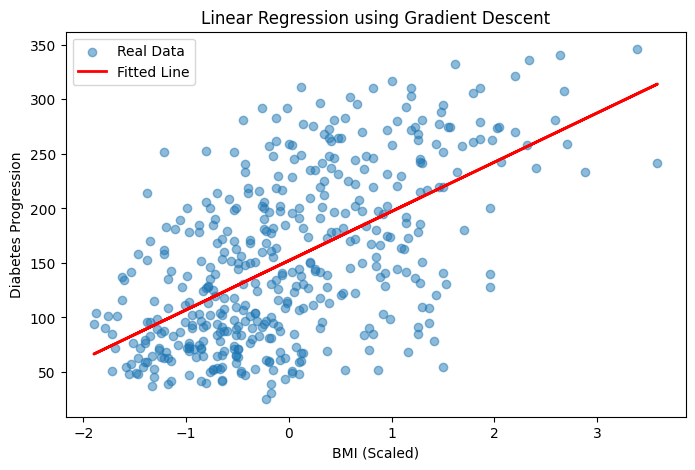

In [ ]:
plt.figure(figsize=(8,5))

# Scatter plot of real data
plt.scatter(X_scaled, y,
            alpha=0.5,
            label="Real Data")

# Regression line
plt.plot(X_scaled,
         m * X_scaled.flatten() + c,
         color='red',
         linewidth=2,
         label="Fitted Line")

plt.xlabel("BMI (Scaled)")
plt.ylabel("Diabetes Progression")
plt.title("Linear Regression using Gradient Descent")
plt.legend()

plt.show()

### Step 8: Plot the Loss Curve

This section visualizes how the loss function decreased over the iterations:

- `plt.figure(figsize=(8,5))`: Creates another new figure for this plot.
- `plt.plot(loss_history)`: Plots the `loss_history` list. The x-axis represents the iteration number, and the y-axis represents the MSE loss at that iteration.
- `plt.xlabel("Iterations")`, `plt.ylabel("Loss (MSE)")`, `plt.title("Loss Curve")`: Set the labels for the axes and the title of the plot.
- `plt.show()`: Displays the loss curve plot. A properly functioning gradient descent should show a decreasing loss curve, indicating that the model is learning.

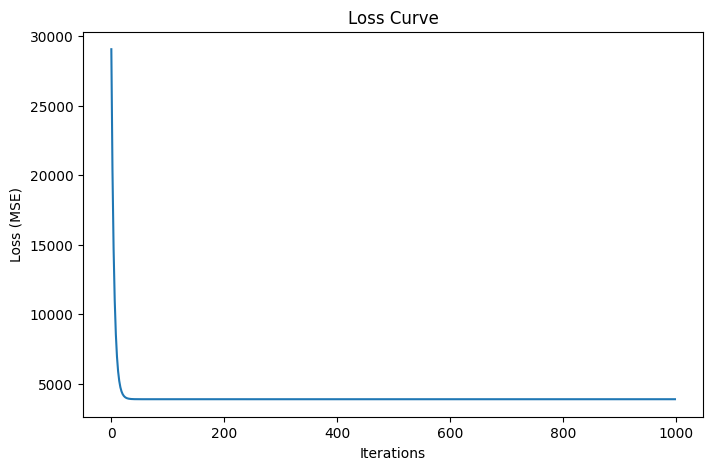

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history_viz) # Use loss_history_viz from the 3D visualization generation
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

### Step 9: 3D Visualization of the Initial Gradient Descent Path

This 3D plot visualizes the path taken by the `m` (slope) and `c` (intercept) parameters during the initial gradient descent process on the cost surface. The red line shows how the parameters iteratively moved towards the minimum of the Mean Squared Error (MSE) cost function.

# Batch Gradient Descent: Batch Gradient Descent computes gradients using the entire dataset in each iteration.
# Stochastic Gradient Descent (SGD): SGD uses one data point per iteration to compute gradients, making it faster.
# Mini-batch Gradient Descent: Mini-batch Gradient Descent combines batch and SGD by using small batches of data for updates.


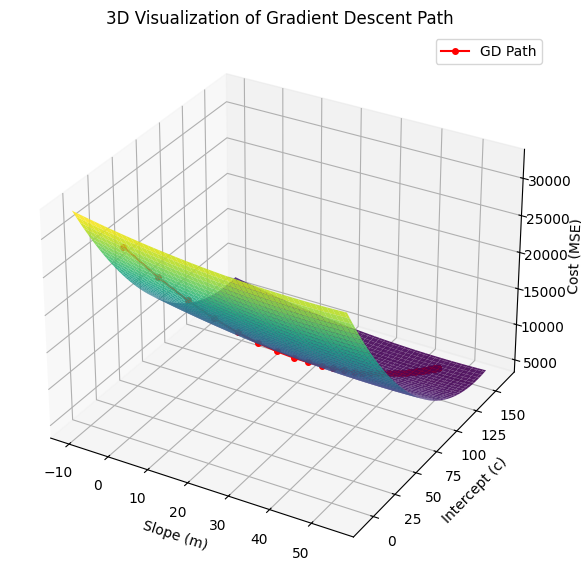

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Redefine the compute_cost_single function to ensure it's available
def compute_cost_single(m_val, c_val, X_data, y_data):
    predictions = m_val * X_data.flatten() + c_val
    return np.mean((predictions - y_data) ** 2)

# --- Data Loading and Scaling (added for self-containment) ---
diabetes = load_diabetes()
X = diabetes.data[:, [2]]
y = diabetes.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# ----------------------------------------------------------------

m_viz = 0.0
c_viz = 0.0
learning_rate_viz = 0.05
iterations_viz = 1000

m_history = []
c_history = []
loss_history_viz = []

for i in range(iterations_viz):
    y_pred = m_viz * X_scaled.flatten() + c_viz
    error = y_pred - y
    loss = np.mean(error ** 2)

    m_history.append(m_viz)
    c_history.append(c_viz)
    loss_history_viz.append(loss)

    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)

    m_viz -= learning_rate_viz * dm
    c_viz -= learning_rate_viz * dc

# Create the cost surface for m and c (re-using the ranges from before)
# Adjusting ranges dynamically based on the history for better visualization
m_vals = np.linspace(min(m_history) - 10, max(m_history) + 10, 100)
c_vals = np.linspace(min(c_history) - 10, max(c_history) + 10, 100)
M, C = np.meshgrid(m_vals, c_vals)

# Calculate J_vals for the surface
J = np.array([compute_cost_single(mv, cv, X_scaled, y) for mv, cv in zip(M.flatten(), C.flatten())]).reshape(M.shape)

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M, C, J, cmap='viridis', alpha=0.9)

# Plot the path of gradient descent
ax.plot(m_history, c_history, loss_history_viz, color='red', marker='o', markersize=4, label='GD Path')

ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('3D Visualization of Gradient Descent Path')
ax.legend()
plt.show()

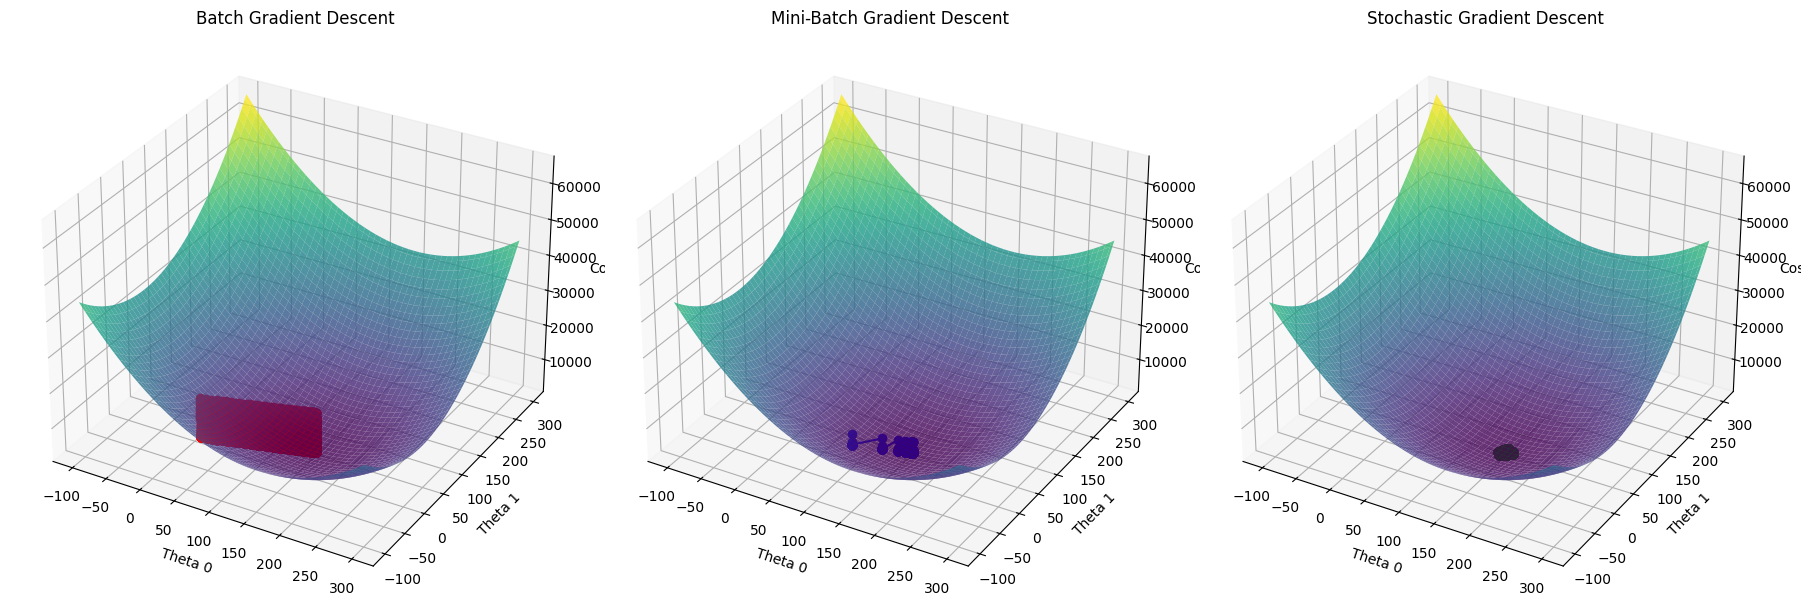

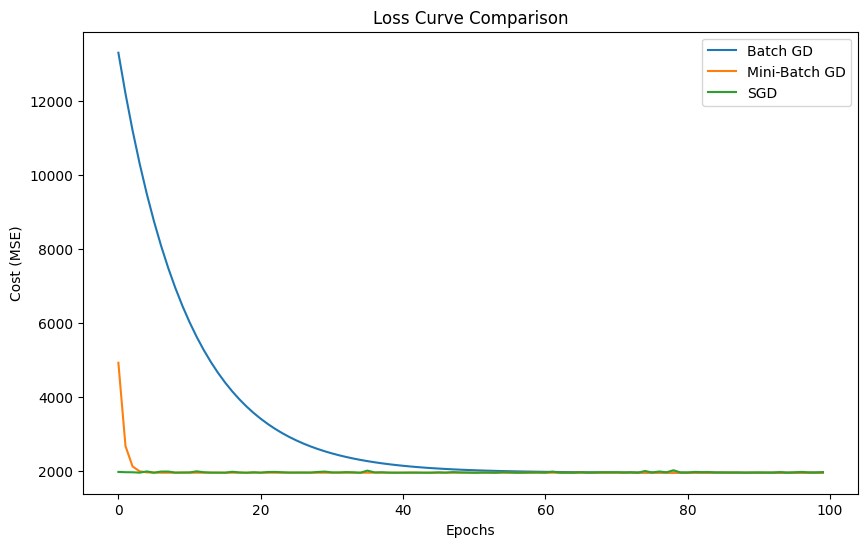

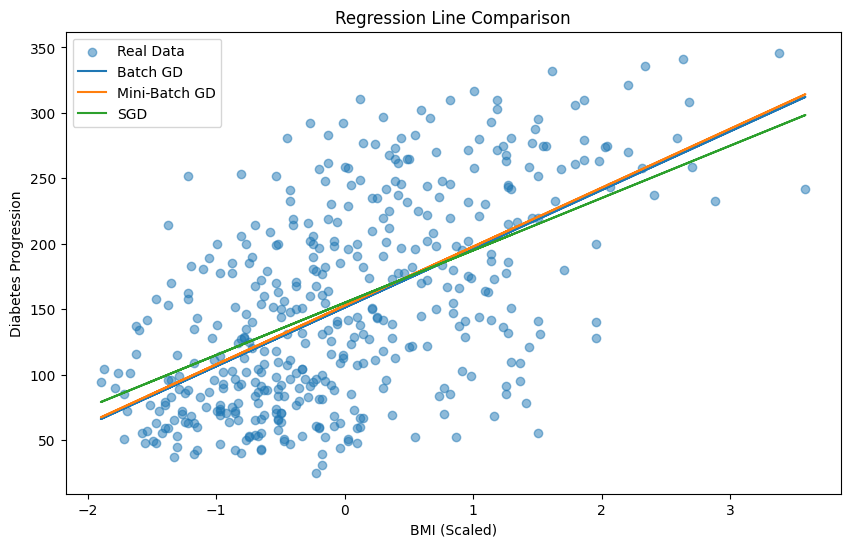


FINAL PARAMETERS

Batch GD
[[151.23277342]
 [ 44.89265874]]

Mini-Batch GD
[[152.80124084]
 [ 45.02878181]]

Stochastic GD
[[154.9433427]
 [ 40.0035464]]


In [ ]:
# =========================================================
# COMPARISON OF:
# 1. Batch Gradient Descent
# 2. Mini-Batch Gradient Descent
# 3. Stochastic Gradient Descent
# USING DIABETES DATASET
# WITH 3D VISUALIZATION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# =========================================================
# STEP 1 — LOAD DATASET
# =========================================================

diabetes = load_diabetes()

# Use only one feature (BMI)
X = diabetes.data[:, [2]]

# Target
y = diabetes.target.reshape(-1, 1)

# Scale feature
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

m = len(X_scaled)

# Add bias column
X_bias = np.c_[np.ones((m, 1)), X_scaled]

# =========================================================
# STEP 2 — COST FUNCTION
# =========================================================

def compute_cost(theta, X, y):

    predictions = X.dot(theta)

    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)

# =========================================================
# STEP 3 — BATCH GRADIENT DESCENT
# =========================================================

def batch_gradient_descent(X, y,
                           learning_rate=0.05,
                           epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        predictions = X.dot(theta)

        gradients = (1 / m) * X.T.dot(predictions - y)

        theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 4 — MINI-BATCH GRADIENT DESCENT
# =========================================================

def mini_batch_gradient_descent(X, y,
                                learning_rate=0.05,
                                epochs=100,
                                batch_size=32):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(0, m, batch_size):

            X_batch = X_shuffled[i:i + batch_size]

            y_batch = y_shuffled[i:i + batch_size]

            predictions = X_batch.dot(theta)

            gradients = (1 / len(X_batch)) * \
                        X_batch.T.dot(predictions - y_batch)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 5 — STOCHASTIC GRADIENT DESCENT
# =========================================================

def stochastic_gradient_descent(X, y,
                                learning_rate=0.01,
                                epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(m):

            xi = X_shuffled[i:i+1]

            yi = y_shuffled[i:i+1]

            predictions = xi.dot(theta)

            gradients = xi.T.dot(predictions - yi)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 6 — TRAIN ALL MODELS
# =========================================================

theta_batch, history_batch, cost_batch = \
    batch_gradient_descent(X_bias, y)

theta_mini, history_mini, cost_mini = \
    mini_batch_gradient_descent(X_bias, y)

theta_sgd, history_sgd, cost_sgd = \
    stochastic_gradient_descent(X_bias, y)

# =========================================================
# STEP 7 — CREATE COST SURFACE
# =========================================================

theta0_vals = np.linspace(-100, 300, 100)

theta1_vals = np.linspace(-100, 300, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):

    for j in range(T0.shape[1]):

        theta_temp = np.array([[T0[i, j]],
                               [T1[i, j]]])

        J_vals[i, j] = compute_cost(theta_temp,
                                    X_bias,
                                    y)

# =========================================================
# STEP 8 — 3D VISUALIZATION
# =========================================================

fig = plt.figure(figsize=(18, 6))

# -----------------------------
# BATCH GD
# -----------------------------

ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax1.plot(history_batch[:, 0],
         history_batch[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_batch],
         color='red',
         marker='o')

ax1.set_title("Batch Gradient Descent")

ax1.set_xlabel("Theta 0")

ax1.set_ylabel("Theta 1")

ax1.set_zlabel("Cost")

# -----------------------------
# MINI-BATCH GD
# -----------------------------

ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax2.plot(history_mini[:, 0],
         history_mini[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_mini],
         color='blue',
         marker='o')

ax2.set_title("Mini-Batch Gradient Descent")

ax2.set_xlabel("Theta 0")

ax2.set_ylabel("Theta 1")

ax2.set_zlabel("Cost")

# -----------------------------
# SGD
# -----------------------------

ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax3.plot(history_sgd[:, 0],
         history_sgd[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_sgd],
         color='green',
         marker='o')

ax3.set_title("Stochastic Gradient Descent")

ax3.set_xlabel("Theta 0")

ax3.set_ylabel("Theta 1")

ax3.set_zlabel("Cost")

plt.tight_layout()

plt.show()

# =========================================================
# STEP 9 — LOSS CURVE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(cost_batch,
         label="Batch GD")

plt.plot(cost_mini,
         label="Mini-Batch GD")

plt.plot(cost_sgd,
         label="SGD")

plt.xlabel("Epochs")

plt.ylabel("Cost (MSE)")

plt.title("Loss Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 10 — REGRESSION LINE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(X_scaled,
            y,
            alpha=0.5,
            label="Real Data")

# Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_batch),
         label="Batch GD")

# Mini-Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_mini),
         label="Mini-Batch GD")

# SGD line
plt.plot(X_scaled,
         X_bias.dot(theta_sgd),
         label="SGD")

plt.xlabel("BMI (Scaled)")

plt.ylabel("Diabetes Progression")

plt.title("Regression Line Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 11 — FINAL PARAMETERS
# =========================================================

print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print("\nBatch GD")
print(theta_batch)

print("\nMini-Batch GD")
print(theta_mini)

print("\nStochastic GD")
print(theta_sgd)

## Comparison of Gradient Descent Variants

This notebook section compares three variants of Gradient Descent (Batch, Mini-Batch, and Stochastic) for a linear regression model applied to the Diabetes dataset. It includes visualizations of the 3D loss surface, loss curves, and fitted regression lines for each method.

### Step 1: Import Libraries and Load Dataset

This step initializes the necessary libraries and prepares the dataset:
- `numpy` for numerical operations.
- `matplotlib.pyplot` for plotting.
- `mpl_toolkits.mplot3d` for 3D visualizations.
- `load_diabetes` from `sklearn.datasets` to get the dataset.
- `StandardScaler` from `sklearn.preprocessing` to normalize the feature.

The dataset is loaded, and only the BMI feature (`X`) is selected and scaled. A bias term is added to `X` to allow for an intercept in the linear model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()

# Use only one feature (BMI)
X = diabetes.data[:, [2]]

# Target
y = diabetes.target.reshape(-1, 1)

# Scale feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

m = len(X_scaled)

# Add bias column (intercept term)
X_bias = np.c_[np.ones((m, 1)), X_scaled]

print("Shape of X (with bias):", X_bias.shape)
print("Shape of y:", y.shape)

Shape of X (with bias): (442, 2)
Shape of y: (442, 1)


### Step 2: Define the Cost Function

The `compute_cost` function calculates the Mean Squared Error (MSE), which is used to evaluate the performance of the linear regression model. It takes the current parameters (`theta`), features (`X`), and actual target values (`y`) as input.

In [ ]:
def compute_cost(theta, X, y):
    predictions = X.dot(theta)
    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)

### Step 3: Implement Batch Gradient Descent (BGD)

Batch Gradient Descent updates the model parameters (`theta`) using the gradients calculated from *all* training examples in each iteration (epoch). This provides a stable gradient but can be computationally expensive for very large datasets.

In [ ]:
def batch_gradient_descent(X, y,
                           learning_rate=0.05,
                           epochs=100):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

### Step 4: Implement Mini-Batch Gradient Descent (MBGD)

Mini-Batch Gradient Descent updates parameters using a small, randomly selected subset of the training data (a 'mini-batch') in each iteration. This offers a compromise between the stability of BGD and the speed of SGD, often leading to faster convergence than BGD while being less noisy than SGD.

In [ ]:
def mini_batch_gradient_descent(X, y,
                                learning_rate=0.05,
                                epochs=100,
                                batch_size=32):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            predictions = X_batch.dot(theta)
            gradients = (1 / len(X_batch)) * \
                        X_batch.T.dot(predictions - y_batch)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

### Step 5: Implement Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent updates parameters using only one randomly chosen training example at a time. This method is very fast per iteration and can escape local minima, but the updates can be noisy, causing the loss to fluctuate more.

In [ ]:
def stochastic_gradient_descent(X, y,
                                learning_rate=0.01,
                                epochs=100):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            predictions = xi.dot(theta)
            gradients = xi.T.dot(predictions - yi)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

### Step 6: Train All Models

Here, each of the three gradient descent algorithms (Batch, Mini-Batch, and Stochastic) are called with the prepared dataset `X_bias` and `y` to train the linear regression models. The function calls return the final optimal parameters (`theta`), the history of parameter updates (`history`), and the cost history over epochs (`cost_history`) for each method.

In [ ]:
theta_batch, history_batch, cost_batch = \
    batch_gradient_descent(X_bias, y)

theta_mini, history_mini, cost_mini = \
    mini_batch_gradient_descent(X_bias, y)

theta_sgd, history_sgd, cost_sgd = \
    stochastic_gradient_descent(X_bias, y)

### Step 7: Create the Cost Surface

To visualize the optimization process in 3D, a cost surface is created. This involves defining a range of possible values for `theta0` (intercept) and `theta1` (slope), and then calculating the `compute_cost` for each combination of these parameters. This generates a 3D surface where the height represents the cost.

In [ ]:
theta0_vals = np.linspace(-100, 300, 100)
theta1_vals = np.linspace(-100, 300, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([[T0[i, j]],
                               [T1[i, j]]])
        J_vals[i, j] = compute_cost(theta_temp,
                                    X_bias,
                                    y)

### Step 8: 3D Visualization of Optimization Paths

This section generates three 3D plots, one for each Gradient Descent variant. Each plot shows the cost surface (representing all possible `theta0` and `theta1` values and their corresponding costs) and superimposes the optimization path taken by each algorithm. The path shows how `theta0` and `theta1` evolved over epochs, tracing their movement towards the minimum of the cost function.

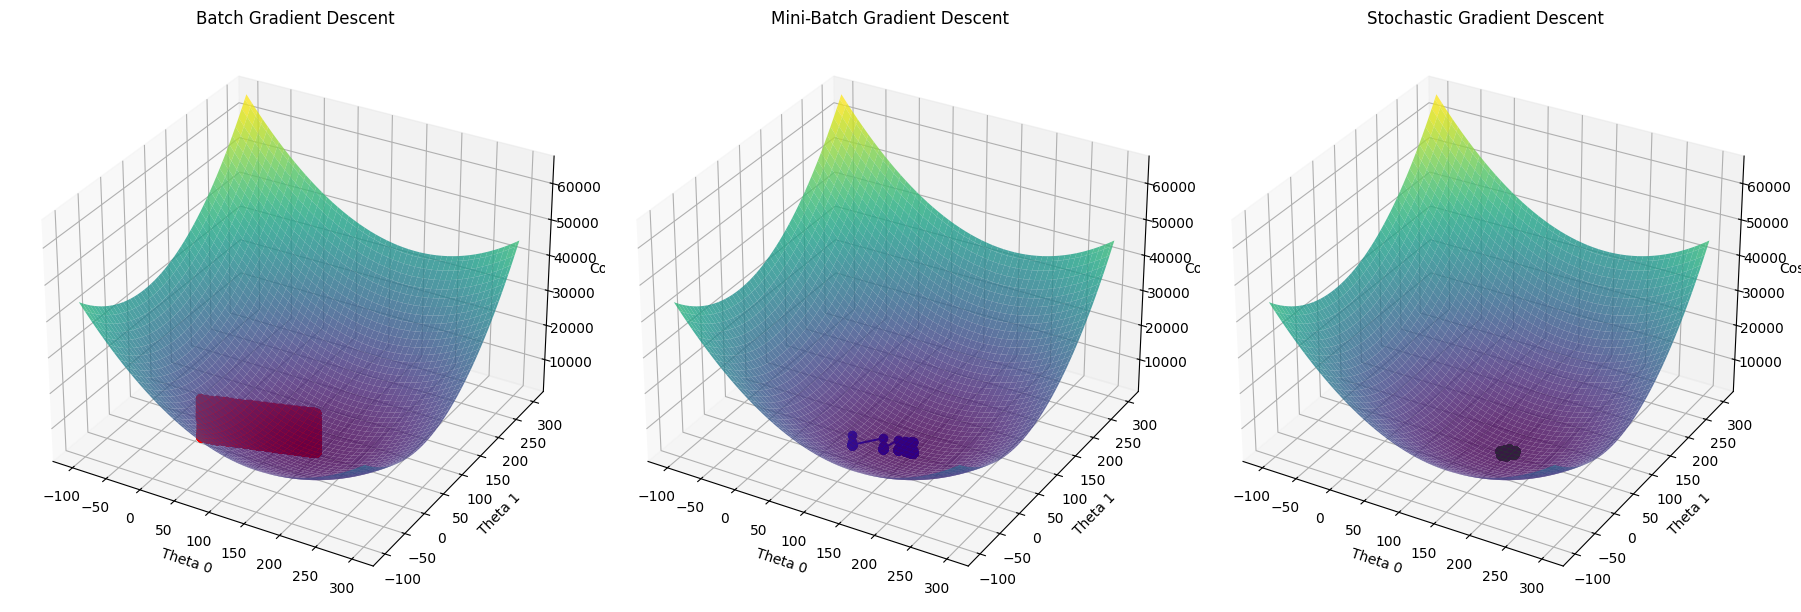

In [ ]:
fig = plt.figure(figsize=(18, 6))

# -----------------------------
# BATCH GD
# -----------------------------
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)
ax1.plot(history_batch[:, 0],
         history_batch[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_batch],
         color='red',
         marker='o')
ax1.set_title("Batch Gradient Descent")
ax1.set_xlabel("Theta 0")
ax1.set_ylabel("Theta 1")
ax1.set_zlabel("Cost")

# -----------------------------
# MINI-BATCH GD
# -----------------------------
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)
ax2.plot(history_mini[:, 0],
         history_mini[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_mini],
         color='blue',
         marker='o')
ax2.set_title("Mini-Batch Gradient Descent")
ax2.set_xlabel("Theta 0")
ax2.set_ylabel("Theta 1")
ax2.set_zlabel("Cost")

# -----------------------------
# SGD
# -----------------------------
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)
ax3.plot(history_sgd[:, 0],
         history_sgd[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_sgd],
         color='green',
         marker='o')
ax3.set_title("Stochastic Gradient Descent")
ax3.set_xlabel("Theta 0")
ax3.set_ylabel("Theta 1")
ax3.set_zlabel("Cost")

plt.tight_layout()
plt.show()

### Step 9: Loss Curve Comparison

This plot visualizes the cost (MSE) over epochs for each of the three Gradient Descent methods. It allows for a direct comparison of their convergence behavior: how quickly and smoothly each algorithm reduces the loss.

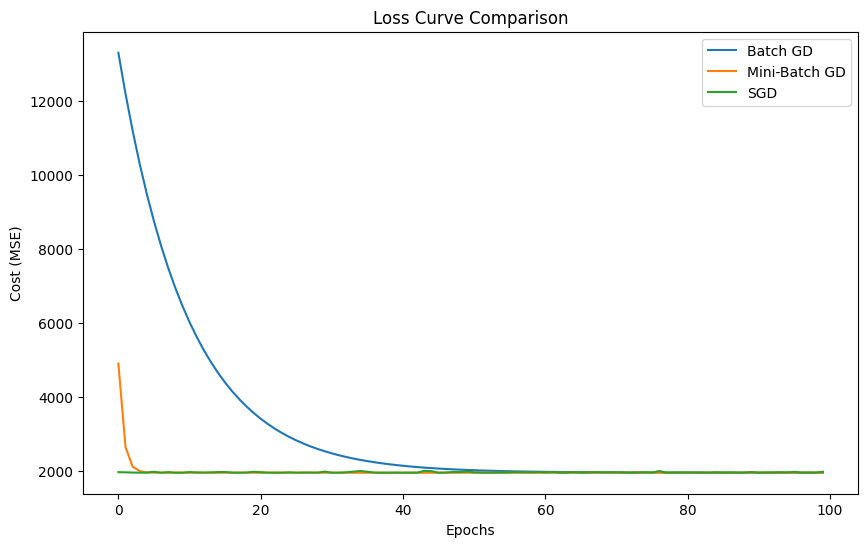

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(cost_batch,
         label="Batch GD")

plt.plot(cost_mini,
         label="Mini-Batch GD")

plt.plot(cost_sgd,
         label="SGD")

plt.xlabel("Epochs")

plt.ylabel("Cost (MSE)")

plt.title("Loss Curve Comparison")

plt.legend()

plt.show()

### Step 10: Regression Line Comparison

This plot displays the original scaled data points along with the final regression lines fitted by each Gradient Descent variant. This helps to visually assess how well each model fits the data based on its learned parameters.

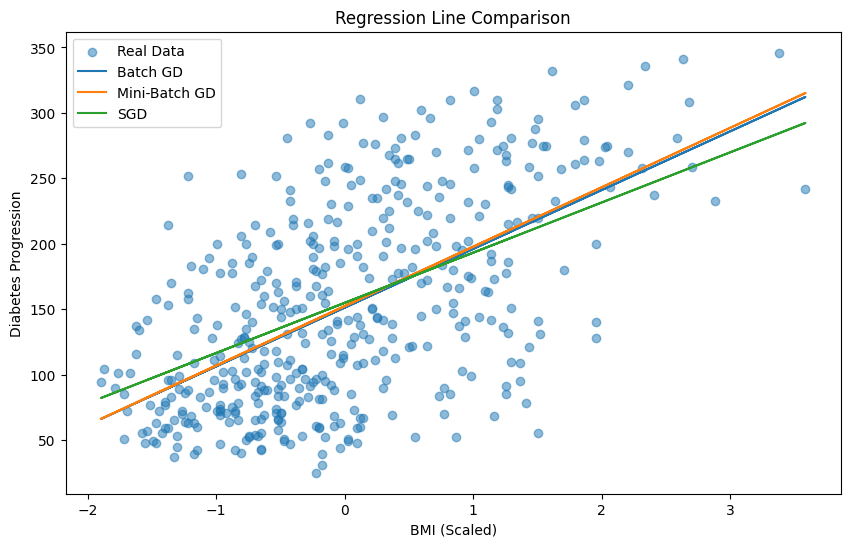

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(X_scaled,
            y,
            alpha=0.5,
            label="Real Data")

# Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_batch),
         label="Batch GD")

# Mini-Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_mini),
         label="Mini-Batch GD")

# SGD line
plt.plot(X_scaled,
         X_bias.dot(theta_sgd),
         label="SGD")

plt.xlabel("BMI (Scaled)")

plt.ylabel("Diabetes Progression")

plt.title("Regression Line Comparison")

plt.legend()

plt.show()

### Step 11: Final Parameters

Finally, this step prints the optimized `theta` values (slope and intercept) for each Gradient Descent method. These values represent the coefficients of the best-fit linear regression lines found by each algorithm.

In [ ]:
print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print("\nBatch GD")
print(theta_batch)

print("\nMini-Batch GD")
print(theta_mini)

print("\nStochastic GD")
print(theta_sgd)


FINAL PARAMETERS

Batch GD
[[151.23277342]
 [ 44.89265874]]

Mini-Batch GD
[[152.33181418]
 [ 45.41811166]]

Stochastic GD
[[154.84797465]
 [ 38.34055499]]
